In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import phoebe
from phoebe import u as _u

# ---------------------------
# RUTAS A TUS ARCHIVOS
# ---------------------------
filepath_r = "D:/archivos_Investigación/PHOEBE}/TYC_6265_2079_flujo_r.txt"
filepath_i = "D:/archivos_Investigación/PHOEBE}/TYC_6265_2079_flujo_i.txt"

In [2]:
data_r = np.genfromtxt(filepath_r, delimiter=None, skip_header=1, encoding='latin1')
time_r = data_r[:, 0]
flux_r = data_r[:, 1]
fluxerr_r = data_r[:, 2]

data_i = np.genfromtxt(filepath_i, delimiter=None, skip_header=1, encoding='latin1')
time_i = data_i[:, 0]
flux_i = data_i[:, 1]
fluxerr_i = data_i[:, 2]


In [3]:
b = phoebe.default_binary()

# 2. CARGA DE DATOS (Asumiendo que time_r, flux_r, etc. ya están en memoria)
b.add_dataset('lc', times=time_r, fluxes=flux_r, sigmas=fluxerr_r, passband='SDSS:r', dataset='lc01')
b.add_dataset('lc', times=time_i, fluxes=flux_i, sigmas=fluxerr_i, passband='SDSS:i', dataset='lc02')

# 3. PARÁMETROS BASE INICIALES
b['period@binary'] = 3.6788 * u.day
b['t0_supconj@binary'] = time_r[0] * u.day
b['incl@binary'] = 70.0 * u.deg
b['q@binary'] = 0.5
b['teff@primary'] = 25700 * u.K
b['teff@secondary'] = 20000 * u.K
b['ecc@binary'] = 0.0

# 4. CONFIGURACIÓN FÍSICA (Volvemos a ck2004 con interpolación)
b.set_value_all('atm', 'ck2004')
b.set_value_all('ld_mode', 'interp')
b.set_value_all('ld_mode_bol', 'manual')
b.set_value_all('gravb_bol', 1.0)
b.set_value_all('irrad_frac_refl_bol', 1.0)
b.set_value_all('pblum_mode', 'dataset-scaled')
b.set_value_all('irrad_method', 'horvat')

# 5. GESTIÓN DE RESTRICCIONES (CONSTRAINTS)
b.flip_constraint('teffratio', solve_for='teff@secondary')
# En sistemas separados, EBAI evalúa la suma de radios para despejar el de la secundaria
b.flip_constraint('requivsumfrac', solve_for='requiv@secondary')

<ConstraintParameter: {requiv@secondary@component} = ({requivsumfrac@binary@component} * {sma@binary@component}) - {requiv@primary@component} (solar units) => 1.0 solRad>

In [4]:
b.add_solver('estimator.ebai', ebai_method='knn', solver='ebai_knn')
b.run_solver('ebai_knn', solution='ebai_knn_solution')

sol = b.get_solution('ebai_knn_solution')
params_to_adopt = sol.get_value('adopt_parameters')

params_filtered = [p for p in params_to_adopt if not ("ecosw" in p or "esinw" in p)]

b.adopt_solution('ebai_knn_solution', adopt_parameters=params_filtered, adopt_values=True)

C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


<ParameterSet: 20 parameters | contexts: dataset, component>

In [5]:
print("R1 (requiv@primary)=", b.get_value('requiv@primary@component'))
print("R2 (requiv@secondary)=", b.get_value('requiv@secondary@component'))

print("Sum (R1+R2)/a=", b.get_value('requivsumfrac@binary@component'))
print("Ratio R1/R2=", b.get_value('requivratio@binary@component'))

print("Teff primary=", b.get_value('teff@primary@component'))
print("Teff secondary=", b.get_value('teff@secondary@component'))

print("Incl=", b.get_value('incl@binary@orbit@component'))
print("Period=", b.get_value('period@binary'))

# Lóbulos de Roche
RL1 = b.get_value('requiv_max@primary@component')
RL2 = b.get_value('requiv_max@secondary@component')

print("Roche lobe 1:", RL1)
print("Roche lobe 2:", RL2)


R1 (requiv@primary)= 1.0
R2 (requiv@secondary)= 0.585251171687559
Sum (R1+R2)/a= 0.29910399465803
Ratio R1/R2= 0.585251171687559
Teff primary= 25700.0
Teff secondary= 23374.95361720044
Incl= 78.11938695015135
Period= 3.6788
Roche lobe 1: 2.342509738772878
Roche lobe 2: 1.6994519588420407


In [6]:
b.run_compute(model='modelo_final', irrad_method='horvat', overwrite=True)

100%|██████████| 167/167 [00:03<00:00, 52.13it/s]


<ParameterSet: 7 parameters | datasets: lc01, lc02>

C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\phoebe\dependencies\autofig\call.py:1305: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  artist = ax.scatter(*datapoint,


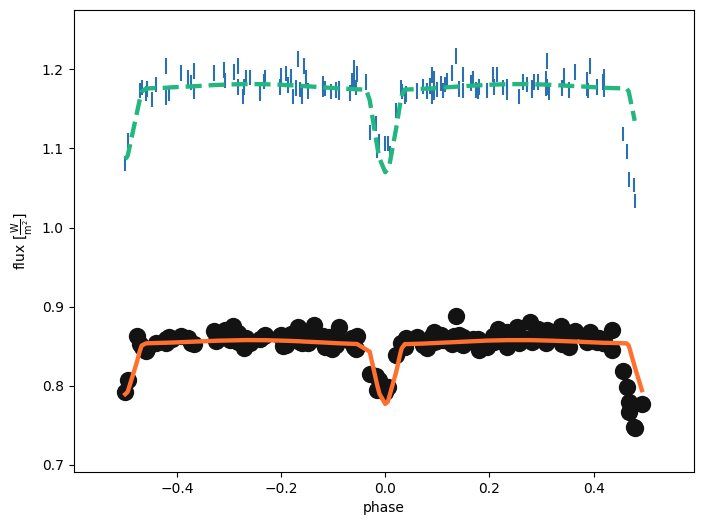

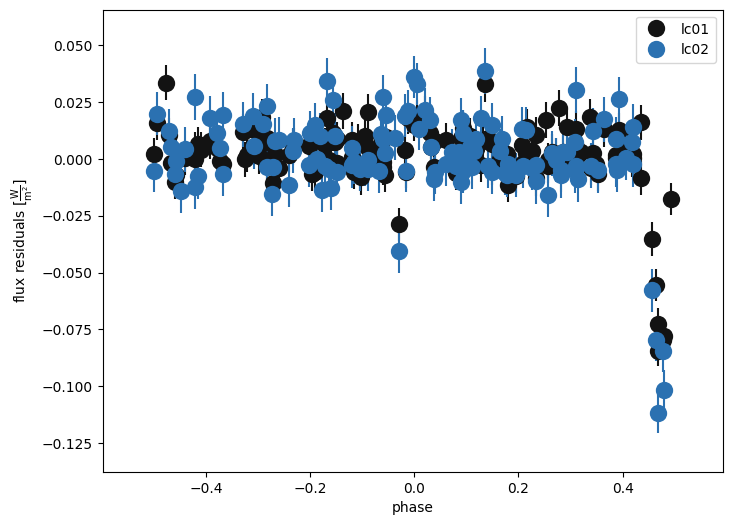

(<autofig.figure.Figure | 1 axes | 2 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [7]:
b.plot(dataset=['lc01', 'lc02'], x='phase', show=True)
b.plot(kind='lc', x='phase', y='residuals', show=True, legend=True, marker='o')

100%|██████████| 170/170 [00:02<00:00, 71.90it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


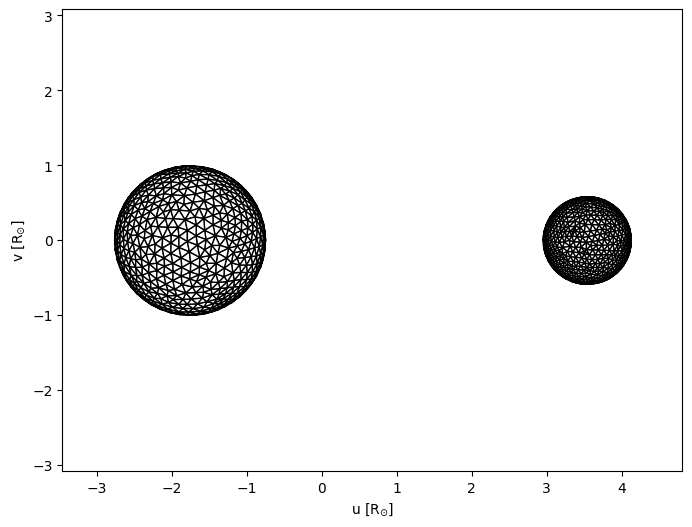

(<autofig.figure.Figure | 1 axes | 2 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [8]:
if 'mesh01' not in b.datasets:
    t0 = b.get_value('t0_supconj@binary')
    period = b.get_value('period@binary')
    # Fases clave: 0.0 (Eclipse Primario), 0.25 (Cuadratura), 0.5 (Eclipse Secundario)
    times_mesh = [t0, t0 + 0.25 * period, t0 + 0.5 * period]
    b.add_dataset('mesh', compute_times=times_mesh, dataset='mesh01')

b.run_compute(model='modelo_separado', irrad_method='horvat', overwrite=True)

# Visualizamos la cuadratura para ver ambas estrellas de perfil
b.plot(kind='mesh', dataset='mesh01', time=times_mesh[1], show=True)

In [15]:
import numpy as np
import multiprocessing

print("Iniciando configuración extrema de velocidad...")

# ==========================================================
# 1. CREAR UN MOTOR DE CÓMPUTO DEDICADO (La forma correcta)
# ==========================================================
# Creamos un perfil de cálculo llamado 'fast_compute'
if 'fast_compute' not in b.computes:
    b.add_compute('phoebe', compute='fast_compute')

# Le inyectamos la configuración de baja resolución y física rápida
b.set_value('ntriangles', compute='fast_compute', value=300) 
b.set_value('irrad_method', compute='fast_compute', value='wilson')

# Desactivamos la interpolación de tablas estelares temporalmente
b.set_value_all('atm', 'blackbody')

# --- ¡AHORA SÍ, MULTIPROCESAMIENTO! ---
nucleos = max(1, multiprocessing.cpu_count() - 2)
b.set_value('nprocs', compute='fast_compute', value=nucleos)
print(f"Motor 'fast_compute' creado utilizando {nucleos} núcleos.")


# ==========================================================
# 2. CONFIGURAR EL OPTIMIZADOR
# ==========================================================
if 'nm_solver' not in b.solvers:
    b.add_solver('optimizer.nelder_mead', solver='nm_solver')

# VINCULACIÓN CRÍTICA: Le decimos al optimizador que use nuestro motor rápido
b.set_value('compute', solver='nm_solver', value='fast_compute')

# Asignamos los parámetros libres que ya sabemos que funcionan
params_to_fit = [
    't0_supconj@binary',
    'incl@binary',
    'teffratio@binary',
    'requivsumfrac@binary',
    'requiv@primary'
]

b.set_value('fit_parameters', solver='nm_solver', value=params_to_fit)
b.set_value('maxiter', solver='nm_solver', value=300)

# ==========================================================
# 3. EJECUCIÓN
# ==========================================================
print("\nIniciando Nelder-Mead hiper-acelerado. Observa la velocidad...")
b.run_solver('nm_solver', solution='nm_solution')

# Resultados
sol_nm = b.get_solution('nm_solution')
print("\n¡Optimización completada! Resultados:")
print(sol_nm)

Iniciando configuración extrema de velocidad...


ValueError: 2 results found: ['ntriangles@primary@fast_compute@phoebe@compute', 'ntriangles@secondary@fast_compute@phoebe@compute']